<a href="https://colab.research.google.com/github/devtemzy/googlecolab-mk/blob/Lab-1---Aug27/Polynomial_Regression_Tutorial_mk.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🎯 Polynomial Regression in Colab — Hands‑On Tutorial

**Goal:** Build, tune, and evaluate a Polynomial Regression model step‑by‑step.

**What you'll learn:**
- When and why to use polynomial regression
- Feature engineering with `PolynomialFeatures`
- Train/validation/test splits and avoiding data leakage
- Model selection with cross‑validation `GridSearchCV`
- Visual diagnostics (learning curves, residuals)
- (Bonus) Regularisation with Ridge to reduce overfitting
- Saving and loading your trained model

> 🧑‍🏫 **Instructor note:** This notebook auto‑generates a mini dataset, but also saves a CSV so students can re‑use it or swap in their own.

## 1) Setup
Run this cell to install/verify the packages you'll use. Colab usually has these pre‑installed.

In [6]:

# If running locally, uncomment the lines below to install dependencies.
# %pip install -q numpy pandas scikit-learn matplotlib ipywidgets

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, learning_curve
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, RidgeCV
from sklearn.metrics import mean_squared_error, r2_score
import joblib
from ipywidgets import interact, IntSlider, FloatSlider, fixed

# For pretty plots in notebooks
%matplotlib inline


## 2) Create & explore the dataset
We'll simulate a realistic non‑linear relationship between **Hours_Studied** (X) and **Exam_Score** (y). This gives us full control of noise and complexity.

In [16]:
# Reproducibility
import os
rng = np.random.default_rng(42)

# Create synthetic dataset
n_samples = 160
X = rng.uniform(0, 9.5, size=n_samples)  # Hours_Studied
# True underlying function (cubic-ish) with noise
y_true = 5 + 3*X - 0.7*(X**2) + 0.08*(X**3)
noise = rng.normal(0, 6.0, size=n_samples)
y = y_true + noise

df = pd.DataFrame({
    "Hours_Studied": X.round(2),
    "Exam_Score": y.round(2)
})

# Save a CSV so you can re-use it or share it
os.makedirs("data", exist_ok=True)
csv_path = "data/study_scores.csv"
df.to_csv(csv_path, index=False)

df.head()

,Hours_Studied,Exam_Score
0,7.35,26.91
1,4.17,8.14
2,8.16,19.20
3,6.62,11.62
4,0.89,2.83


### Quick look at distributions

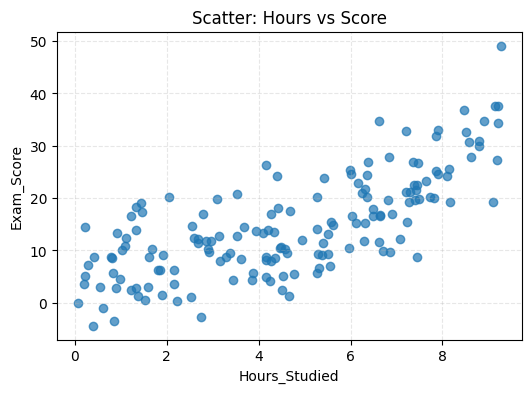

In [8]:

fig = plt.figure(figsize=(6,4))
plt.scatter(df["Hours_Studied"], df["Exam_Score"], alpha=0.7)
plt.xlabel("Hours_Studied")
plt.ylabel("Exam_Score")
plt.title("Scatter: Hours vs Score")
plt.grid(True, linestyle="--", alpha=0.3)
plt.show()


> 🧪 **Your turn:** Duplicate the data cell and try changing `n_samples`, the noise scale, or the polynomial coefficients to see how the task becomes easier or harder.

# Changing the number of Samples

In [9]:
# Reproducibility
import os
rng = np.random.default_rng(42)

# Create synthetic dataset
n_samples = 250 #changed from 160 to 250
X = rng.uniform(0, 9.5, size=n_samples)  # Hours_Studied
# True underlying function (cubic-ish) with noise
y_true = 5 + 3*X - 0.7*(X**2) + 0.08*(X**3)
noise = rng.normal(0, 6.0, size=n_samples)
y = y_true + noise

df = pd.DataFrame({
    "Hours_Studied": X.round(2),
    "Exam_Score": y.round(2)
})

# Save a CSV so you can re-use it or share it
os.makedirs("data", exist_ok=True)
csv_path = "data/study_scores.csv"
df.to_csv(csv_path, index=False)

df.head()

,Hours_Studied,Exam_Score
0,7.35,20.45
1,4.17,0.59
2,8.16,17.51
3,6.62,30.19
4,0.89,-0.54


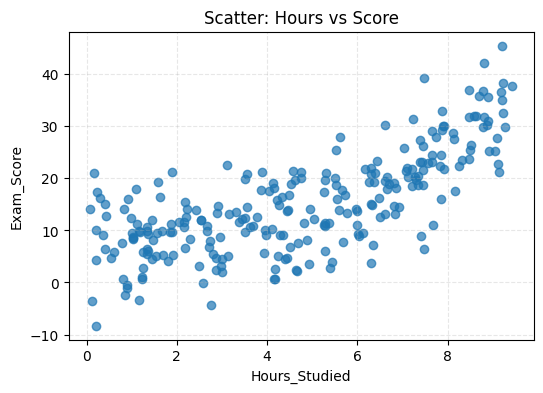

In [10]:

fig = plt.figure(figsize=(6,4))
plt.scatter(df["Hours_Studied"], df["Exam_Score"], alpha=0.7)
plt.xlabel("Hours_Studied")
plt.ylabel("Exam_Score")
plt.title("Scatter: Hours vs Score")
plt.grid(True, linestyle="--", alpha=0.3)
plt.show()


### Changing the noise

In [11]:
# Reproducibility
import os
rng = np.random.default_rng(42)

# Create synthetic dataset
n_samples = 160
X = rng.uniform(0, 9.5, size=n_samples)  # Hours_Studied
# True underlying function (cubic-ish) with noise
y_true = 5 + 3*X - 0.7*(X**2) + 0.08*(X**3)
noise = rng.normal(0, 10.0, size=n_samples) # 6.0 to 10.0
y = y_true + noise

df = pd.DataFrame({
    "Hours_Studied": X.round(2),
    "Exam_Score": y.round(2)
})

# Save a CSV so you can re-use it or share it
os.makedirs("data", exist_ok=True)
csv_path = "data/study_scores.csv"
df.to_csv(csv_path, index=False)

df.head()

,Hours_Studied,Exam_Score
0,7.35,30.84
1,4.17,6.14
2,8.16,14.46
3,6.62,7.76
4,0.89,-0.07


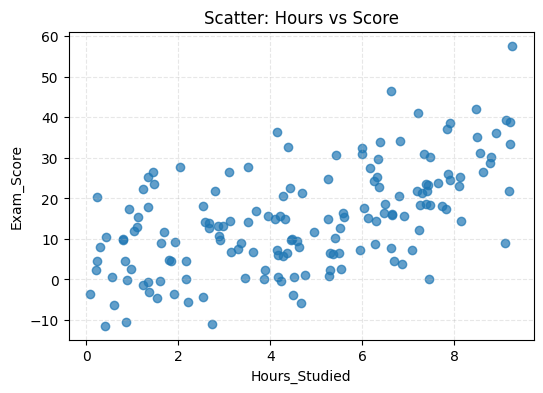

In [12]:

fig = plt.figure(figsize=(6,4))
plt.scatter(df["Hours_Studied"], df["Exam_Score"], alpha=0.7)
plt.xlabel("Hours_Studied")
plt.ylabel("Exam_Score")
plt.title("Scatter: Hours vs Score")
plt.grid(True, linestyle="--", alpha=0.3)
plt.show()


## Changing the coefficients

In [13]:
# Reproducibility
import os
rng = np.random.default_rng(42)

# Create synthetic dataset
n_samples = 160
X = rng.uniform(0, 9.5, size=n_samples)  # Hours_Studied
# True underlying function (cubic-ish) with noise
y_true = 5 + 2*X - 5*(X**2) + 8*(X**3)  # The coefficients are 3 to 2, -0.7 to -5, and +0.08 to 8
noise = rng.normal(0, 6.0, size=n_samples)
y = y_true + noise

df = pd.DataFrame({
    "Hours_Studied": X.round(2),
    "Exam_Score": y.round(2)
})

# Save a CSV so you can re-use it or share it
os.makedirs("data", exist_ok=True)
csv_path = "data/study_scores.csv"
df.to_csv(csv_path, index=False)

df.head()

,Hours_Studied,Exam_Score
0,7.35,2935.17
1,4.17,503.25
2,8.16,4022.95
3,6.62,2119.21
4,0.89,4.16


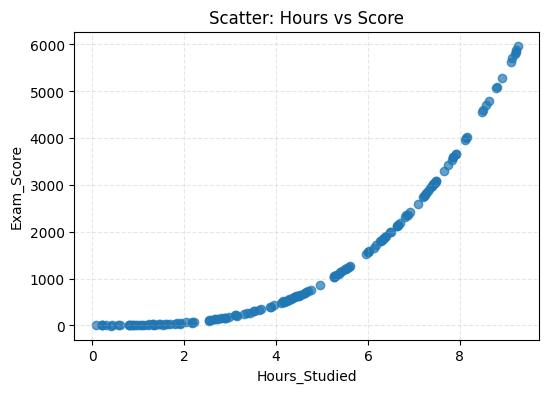

In [14]:

fig = plt.figure(figsize=(6,4))
plt.scatter(df["Hours_Studied"], df["Exam_Score"], alpha=0.7)
plt.xlabel("Hours_Studied")
plt.ylabel("Exam_Score")
plt.title("Scatter: Hours vs Score")
plt.grid(True, linestyle="--", alpha=0.3)
plt.show()


# For Task 10: Our Reproduction and Adding A New Feature

In [29]:
# Reproducibility
import os
rng = np.random.default_rng(42)

# Create synthetic dataset
n_samples = 250 # changed number of samples
X = rng.uniform(0, 9.5, size=n_samples)  # Hours_Studied
# True underlying function (cubic-ish) with noise
y_true = 5 + 2*X - 0.0075*(X**2) + 0.1*(X**3) # changed the polonomial coefficients
noise = rng.normal(0, 6.0, size=n_samples)
y = y_true + noise

df = pd.DataFrame({
    "Hours_Studied": X.round(2),
    "Exam_Score": y.round(2)
})

# Save a CSV so you can re-use it or share it
os.makedirs("data", exist_ok=True)
csv_path = "data/study_scores_new.csv"
df.to_csv(csv_path, index=False)

df.head()

,Hours_Studied,Exam_Score
0,7.35,58.48
1,4.17,9.91
2,8.16,66.28
3,6.62,59.77
4,0.89,-0.87


## 3) Split the data
We'll keep a test set aside and use the rest for training and validation.

In [17]:
# rerun with the original data before the reproductions
X_all = df[["Hours_Studied"]].values
y_all = df["Exam_Score"].values

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.2, random_state=7
)

len(X_train), len(X_test)


(128, 32)

## 4) Baseline: simple linear regression
This will likely **underfit** because the true relationship is curved.

Test RMSE (Linear): 6.519069547185539
Test R² (Linear): 0.43598927232097406


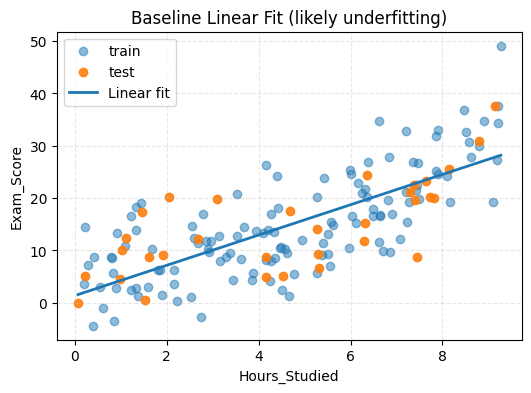

In [19]:
linreg = LinearRegression()
linreg.fit(X_train, y_train)

y_pred_lin = linreg.predict(X_test)
# Calculate RMSE manually by taking the square root
rmse_lin = np.sqrt(mean_squared_error(y_test, y_pred_lin))
print("Test RMSE (Linear):", rmse_lin)
print("Test R² (Linear):", r2_score(y_test, y_pred_lin))

# Visualize fit on a dense grid
x_grid = np.linspace(X_all.min(), X_all.max(), 200).reshape(-1, 1)
y_line = linreg.predict(x_grid)

plt.figure(figsize=(6,4))
plt.scatter(X_train, y_train, alpha=0.5, label="train")
plt.scatter(X_test, y_test, alpha=0.9, label="test")
plt.plot(x_grid, y_line, linewidth=2, label="Linear fit")
plt.xlabel("Hours_Studied"); plt.ylabel("Exam_Score")
plt.title("Baseline Linear Fit (likely underfitting)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.3)
plt.show()

## 5) Polynomial features + grid search
We'll try degrees 1‑10 and use cross‑validation to pick the best degree.

Best degree: 2
CV RMSE (negative): -6.180271635982896
Test RMSE (Best Poly): 6.022371473585227
Test R² (Best Poly): 0.5186608168995765


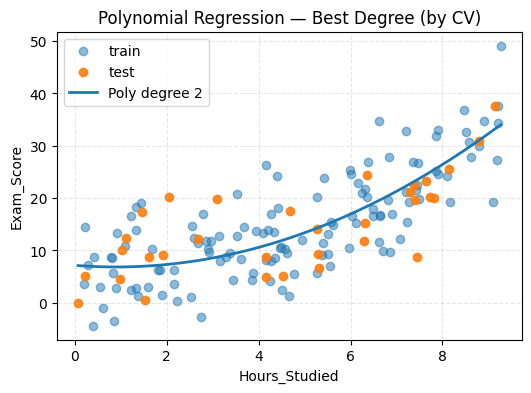

In [20]:
pipe = Pipeline([
    ("poly", PolynomialFeatures(include_bias=False)),
    ("lin", LinearRegression())
])

param_grid = {"poly__degree": list(range(1, 11))}

grid = GridSearchCV(
    pipe, param_grid=param_grid, cv=5, scoring="neg_root_mean_squared_error", n_jobs=-1
)
grid.fit(X_train, y_train)

print("Best degree:", grid.best_params_["poly__degree"])
print("CV RMSE (negative):", grid.best_score_)

best_model = grid.best_estimator_

y_pred = best_model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print("Test RMSE (Best Poly):", rmse)
print("Test R² (Best Poly):", r2)

# Plot the curve
x_grid = np.linspace(X_all.min(), X_all.max(), 400).reshape(-1, 1)
y_grid = best_model.predict(x_grid)

plt.figure(figsize=(6,4))
plt.scatter(X_train, y_train, alpha=0.5, label="train")
plt.scatter(X_test, y_test, alpha=0.9, label="test")
plt.plot(x_grid, y_grid, linewidth=2, label=f"Poly degree {grid.best_params_['poly__degree']}")
plt.xlabel("Hours_Studied"); plt.ylabel("Exam_Score")
plt.title("Polynomial Regression — Best Degree (by CV)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.3)
plt.show()

### 🎚️ Try it interactively: choose the polynomial degree
Use the slider to see how the curve changes and how overfitting can appear.

In [21]:

def fit_degree(degree, X_train, y_train, X_all):
    model = Pipeline([
        ("poly", PolynomialFeatures(degree=degree, include_bias=False)),
        ("lin", LinearRegression())
    ])
    model.fit(X_train, y_train)

    x_grid = np.linspace(X_all.min(), X_all.max(), 400).reshape(-1, 1)
    y_grid = model.predict(x_grid)
    return x_grid, y_grid

@interact(degree=IntSlider(min=1, max=12, step=1, value=grid.best_params_['poly__degree']))
def show_curve(degree):
    x_grid, y_grid = fit_degree(degree, X_train, y_train, X_all)
    plt.figure(figsize=(6,4))
    plt.scatter(X_train, y_train, alpha=0.5, label="train")
    plt.scatter(X_test, y_test, alpha=0.9, label="test")
    plt.plot(x_grid, y_grid, linewidth=2, label=f"degree = {degree}")
    plt.xlabel("Hours_Studied"); plt.ylabel("Exam_Score")
    plt.title("Interactive Polynomial Fit")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.3)
    plt.show()


interactive(children=(IntSlider(value=2, description='degree', max=12, min=1), Output()), _dom_classes=('widge…

## 6) Residual diagnostics
Residuals should look like random noise if the model is well‑specified.

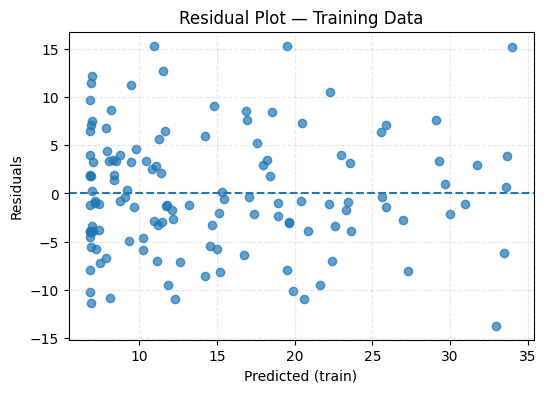

In [22]:

y_pred_train = best_model.predict(X_train)
residuals = y_train - y_pred_train

plt.figure(figsize=(6,4))
plt.scatter(y_pred_train, residuals, alpha=0.7)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted (train)")
plt.ylabel("Residuals")
plt.title("Residual Plot — Training Data")
plt.grid(True, linestyle="--", alpha=0.3)
plt.show()


## 7) Learning curve
Helps you see bias/variance behaviour as you vary the training size.

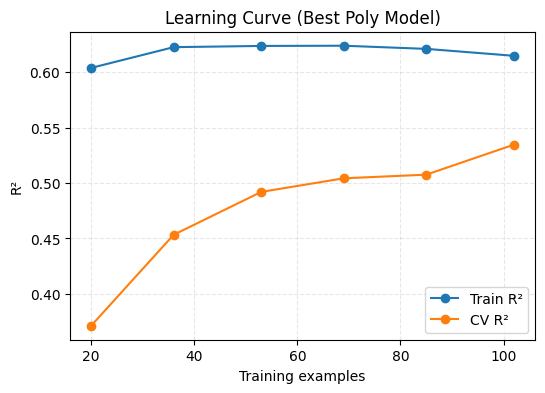

In [23]:

train_sizes, train_scores, valid_scores = learning_curve(
    best_model, X_train, y_train, cv=5, scoring="r2",
    train_sizes=np.linspace(0.2, 1.0, 6), n_jobs=-1, shuffle=True, random_state=7
)

train_mean = train_scores.mean(axis=1)
valid_mean = valid_scores.mean(axis=1)

plt.figure(figsize=(6,4))
plt.plot(train_sizes, train_mean, marker="o", label="Train R²")
plt.plot(train_sizes, valid_mean, marker="o", label="CV R²")
plt.xlabel("Training examples")
plt.ylabel("R²")
plt.title("Learning Curve (Best Poly Model)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.3)
plt.show()


## 8) (Bonus) Regularisation with Ridge
High‑degree polynomials may overfit. Ridge can help by shrinking coefficients.

In [24]:

ridge_pipe = Pipeline([
    ("poly", PolynomialFeatures(degree=10, include_bias=False)),  # try a high degree
    ("ridge", Ridge())
])

alphas = np.logspace(-4, 4, 30)
ridge_cv = GridSearchCV(ridge_pipe, {"ridge__alpha": alphas}, cv=5, scoring="r2", n_jobs=-1)
ridge_cv.fit(X_train, y_train)

print("Best alpha (Ridge):", ridge_cv.best_params_["ridge__alpha"])
print("Best CV R² (Ridge):", ridge_cv.best_score_)

ridge_best = ridge_cv.best_estimator_
y_pred_ridge = ridge_best.predict(X_test)
print("Test R² (Ridge, deg=10):", r2_score(y_test, y_pred_ridge))


Best alpha (Ridge): 0.0001
Best CV R² (Ridge): 0.4829487057301446
Test R² (Ridge, deg=10): 0.27963616577786876


/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=2.62529e-24): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)


## 9) Save & load your model
Great for deploying or re‑using later.

In [25]:

joblib.dump(best_model, "polynomial_model.joblib")
print("Saved model to polynomial_model.joblib")

# Example: load and predict for a new student
loaded = joblib.load("polynomial_model.joblib")
new_hours = np.array([[5.0], [8.0]])
pred = loaded.predict(new_hours)
for h, p in zip(new_hours.ravel(), pred):
    print(f"Hours={h:.1f} -> Predicted Score={p:.2f}")


Saved model to polynomial_model.joblib
Hours=5.0 -> Predicted Score=13.35
Hours=8.0 -> Predicted Score=26.39


## 10) Mini‑challenges (for marks 🏅)
1. **Try your own dataset:** Replace `df` with your own CSV (`Hours_Studied,Exam_Score`). Re‑run cells.
2. **Add a feature:** Add `Sleep_Hours` and regenerate the dataset as `y = f(Hours, Sleep) + noise`. Update the pipeline and compare R².
3. **Plot predictions vs. truth:** Plot `y_true` vs `y_pred` on the test set and compute RMSE and MAE.
4. **Regularisation comparison:** Compare Ridge and Lasso for degree=12 using cross‑validation.
5. **Report:** In 1–2 paragraphs, explain the best degree you found, why, and show your residual plot.

> Tip: Make screenshots of your best plots for submission.

## Colab Tips
- To upload a CSV: *Files* panel → *Upload* or use `from google.colab import files; files.upload()`.
- To download results: `from google.colab import files; files.download('polynomial_model.joblib')`.
- If widgets don't show, run: `pip install ipywidgets` and then **Runtime → Restart**.

### REPORT - Mutembo Kababa | 202103072

## TASKS 2 & 3:
